# Toy Schedules Generation

Generate a population (schedules and attributes). Where every schedule is home -> ACTIVITY -> home, with varying durations. Where ACTIVITY depends on work_status attribute.

In [ ]:
import random
from pathlib import Path

import pandas as pd
from acteval.describe.times import (
    joint_time_distributions_plot,
    times_distributions_plot,
)
from acteval.describe.transitions import sequence_prob_plot
from numpy.random import choice

In [2]:
n = 10000
ps = {
    "employed": [0.8, 0.0, 0.2],
    "student": [0.2, 0.6, 0.2],
    "unemployed": [0.1, 0.1, 0.8],
}

schedules_write_path = Path("tmp/toy_noisy_schedules.csv")
attributes_write_path = Path("tmp/toy_noisy_attributes.csv")

In [3]:
pid = []
pids = []
acts = []
starts = []
ends = []
durations = []
work_statuses = []

for i in range(n):
    pid.append(i)
    work_status = random.choice(["employed", "student", "unemployed"])
    probs = ps
    activity = choice(["work", "education", "other"], p=probs[work_status])
    work_statuses.append(work_status)

    budget = 1440
    sequence = ["home"]
    seq_durations = []

    if activity in ["work", "education"]:
        departure_time = random.randint(400, 500)
    else:
        departure_time = random.randint(500, 800)
    seq_durations.append(departure_time)
    budget -= departure_time

    sequence.append(activity)
    if activity == "other":
        act_duration = random.randint(60, 180)
    elif activity == "work":
        act_duration = random.randint(400, 600)
    else:
        act_duration = random.randint(300, 500)
    seq_durations.append(act_duration)
    budget -= act_duration

    if budget > 600:
        sequence.append("home")
        home_duration = random.randint(60, 240)
        seq_durations.append(home_duration)
        budget -= home_duration
        sequence.append("other")
        act_duration = random.randint(60, 180)
        seq_durations.append(act_duration)
        budget -= act_duration

    sequence.append("home")
    seq_durations.append(budget)
    home_duration = budget

    t = 0
    for act, duration in zip(sequence, seq_durations):
        pids.append(i)
        acts.append(act)
        starts.append(t)
        t += duration
        ends.append(t)
        durations.append(duration)

schedules = pd.DataFrame(
    {
        "pid": pids,
        "act": acts,
        "start": starts,
        "end": ends,
        "duration": durations,
    }
)

attributes = pd.DataFrame({"pid": pid, "work_status": work_statuses})

print(schedules.head(20))
print(attributes.head())

    pid        act  start   end  duration
0     0       home      0   415       415
1     0       work    415   863       448
2     0       home    863  1440       577
3     1       home      0   727       727
4     1      other    727   819        92
5     1       home    819   968       149
6     1      other    968  1146       178
7     1       home   1146  1440       294
8     2       home      0   428       428
9     2  education    428   913       485
10    2       home    913  1440       527
11    3       home      0   621       621
12    3      other    621   697        76
13    3       home    697   783        86
14    3      other    783   949       166
15    3       home    949  1440       491
16    4       home      0   642       642
17    4      other    642   783       141
18    4       home    783   975       192
19    4      other    975  1081       106
   pid work_status
0    0  unemployed
1    1  unemployed
2    2     student
3    3     student
4    4     student


In [4]:
schedules_write_path.parent.mkdir(exist_ok=True)
attributes_write_path.parent.mkdir(exist_ok=True)
schedules.to_csv(schedules_write_path, index=False)
attributes.to_csv(attributes_write_path, index=False)

In [5]:
def describe_col(population, col: str) -> pd.DataFrame:
    description = population.groupby("act")[col].describe()[
        ["count", "mean", "std", "min", "max"]
    ]
    description["attribute"] = col
    return description


def describe_cols(population, cols: list[str]) -> pd.DataFrame:
    description = pd.concat(
        [describe_col(population, c) for c in cols], ignore_index=False
    )
    description = description.reset_index().set_index(["attribute", "act"])
    return description


describe_cols(schedules, ["start", "end", "duration"]).round()

count   mean    std    min     max
attribute act                                            
start     education   2330.0  451.0   29.0  400.0   500.0
          home       24103.0  527.0  455.0    0.0  1238.0
          other       8099.0  774.0  151.0  500.0  1078.0
          work        3674.0  450.0   29.0  400.0   500.0
end       education   2330.0  850.0   64.0  702.0   999.0
          home       24103.0  970.0  424.0  400.0  1440.0
          other       8099.0  894.0  154.0  563.0  1238.0
          work        3674.0  950.0   66.0  803.0  1097.0
duration  education   2330.0  399.0   58.0  300.0   500.0
          home       24103.0  443.0  165.0   60.0   800.0
          other       8099.0  120.0   35.0   60.0   180.0
          work        3674.0  500.0   58.0  400.0   600.0

In [6]:
def time_distributions(population: pd.DataFrame, mapping: dict):
    starts = {k: [] for k in mapping.values()}
    ends = {k: [] for k in mapping.values()}
    durations = {k: [] for k in mapping.values()}
    for act, acts in population.groupby("act"):
        starts[act] = list(acts.start)
        ends[act] = list(acts.end)
        durations[act] = list(acts.duration)
    return starts, ends, durations

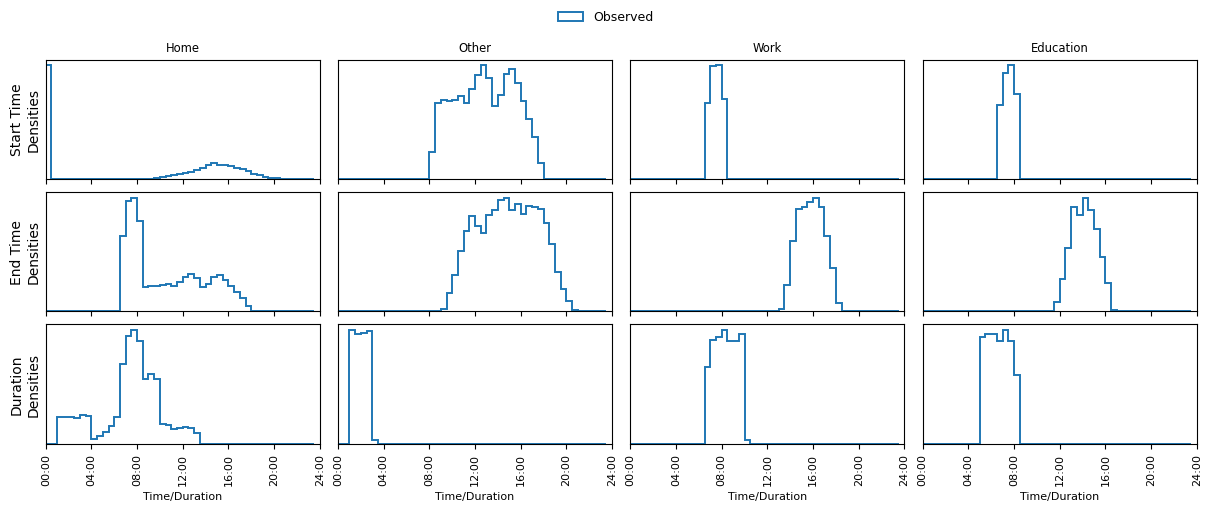

In [7]:
_ = times_distributions_plot(schedules, ys={})

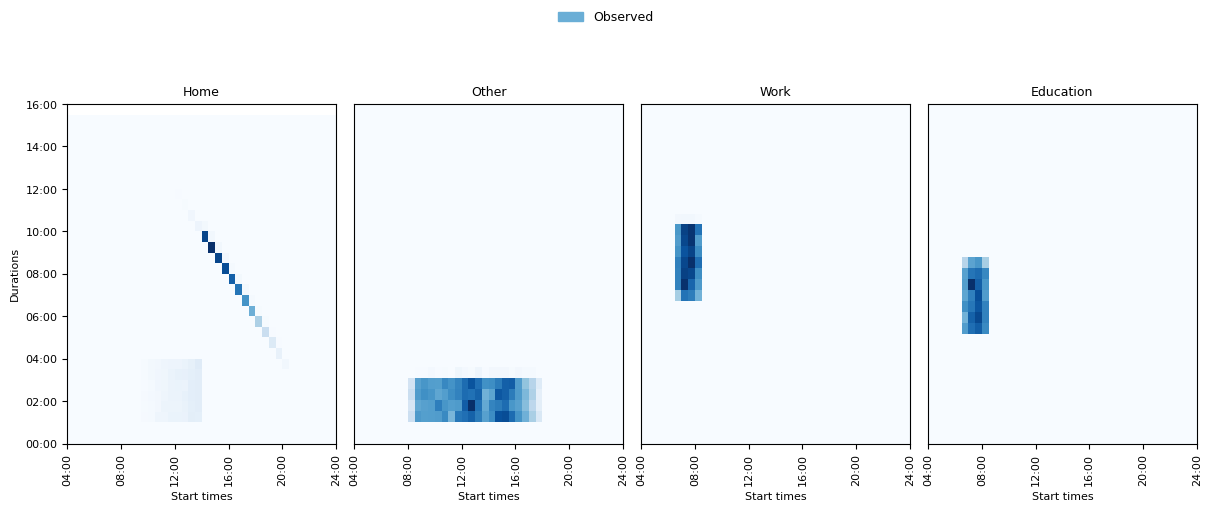

In [8]:
_ = joint_time_distributions_plot(schedules, ys={})

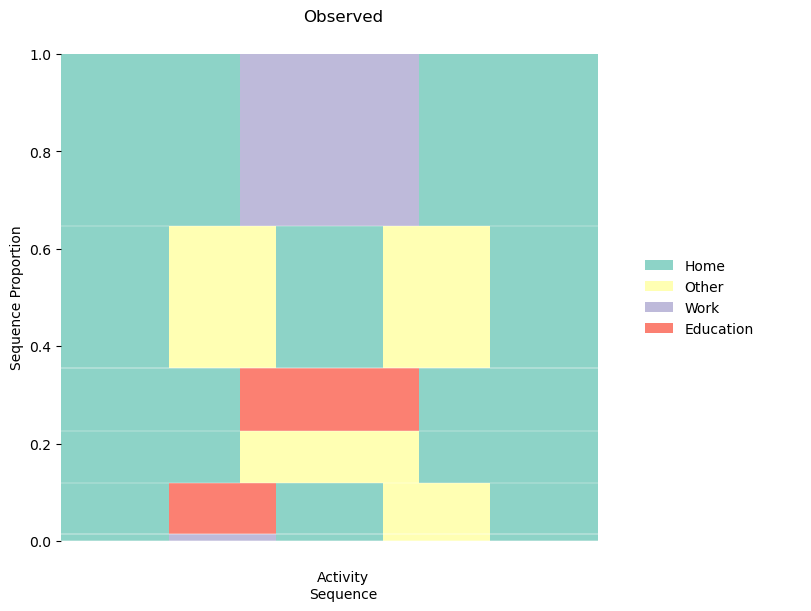

In [9]:
_ = sequence_prob_plot(schedules, ys={}, figsize=(8, 6))